## 1.SYNTHETIC DATASET GENERATION

In [4]:
import random
import csv

services = [
    "Mobile Network",
    "Broadband Service",
    "Billing & Payments",
    "Customer Support",
    "Mobile App Issues",
    "Service Activation"
]

positive_templates = [
    "The {service} is excellent and working perfectly",
    "Really happy with the {service}",
    "{service} has improved a lot recently",
    "Great experience using {service}",
    "{service} is fast and reliable"
]

negative_templates = [
    "The {service} is very poor and disappointing",
    "Facing constant issues with {service}",
    "{service} is extremely unreliable",
    "Very bad experience with {service}",
    "{service} needs serious improvement"
]

neutral_templates = [
    "{service} is okay but nothing special",
    "Average experience with {service}",
    "{service} works fine sometimes",
    "No major issues but could be better in {service}",
    "{service} is acceptable for now"
]

mixed_templates = [
    "The {service} is good but has some issues",
    "I like the {service} but it needs improvement",
    "{service} works well sometimes but fails often",
    "There are both good and bad aspects of {service}",
    "{service} is fast but frequently disconnects"
]

def generate_feedback(templates, sentiment, count):
    data = []
    for _ in range(count):
        service = random.choice(services)
        template = random.choice(templates)
        feedback = template.format(service=service)
        data.append([feedback, sentiment, service])
    return data

dataset = []

dataset += generate_feedback(positive_templates, "Positive", 3000)
dataset += generate_feedback(negative_templates, "Negative", 3000)
dataset += generate_feedback(neutral_templates, "Neutral", 3000)
dataset += generate_feedback(mixed_templates, "Mixed", 1000)

random.shuffle(dataset)

with open("telecom_feedback_dataset.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["feedback", "sentiment", "service_category"])
    writer.writerows(dataset)

print("✅ Dataset with 10,000 rows generated!")

✅ Dataset with 10,000 rows generated!


In [5]:
import pandas as pd

df = pd.read_csv("telecom_feedback_dataset.csv")

print(df.head())
print(df['sentiment'].value_counts())
print(df['service_category'].value_counts())

                                            feedback sentiment  \
0     Billing & Payments has improved a lot recently  Positive   
1      Facing constant issues with Broadband Service  Negative   
2  Mobile App Issues works well sometimes but fai...     Mixed   
3           Great experience using Mobile App Issues  Positive   
4      Broadband Service has improved a lot recently  Positive   

     service_category  
0  Billing & Payments  
1   Broadband Service  
2   Mobile App Issues  
3   Mobile App Issues  
4   Broadband Service  
sentiment
Positive    3000
Negative    3000
Neutral     3000
Mixed       1000
Name: count, dtype: int64
service_category
Customer Support      1728
Mobile App Issues     1675
Broadband Service     1669
Billing & Payments    1664
Service Activation    1633
Mobile Network        1631
Name: count, dtype: int64


## 2.EDA

### Sentiment Distribution

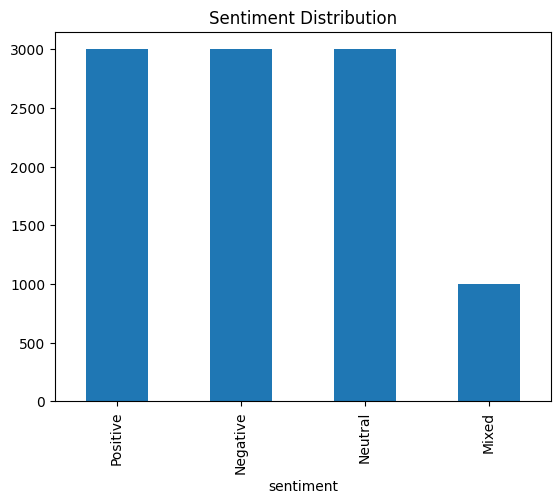

In [6]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

### Service Category Distribution

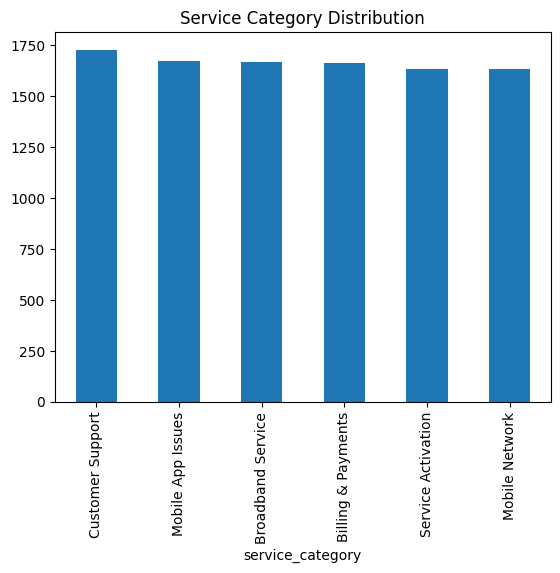

In [7]:
df['service_category'].value_counts().plot(kind='bar')
plt.title("Service Category Distribution")
plt.show()

### Sentiment vs Category

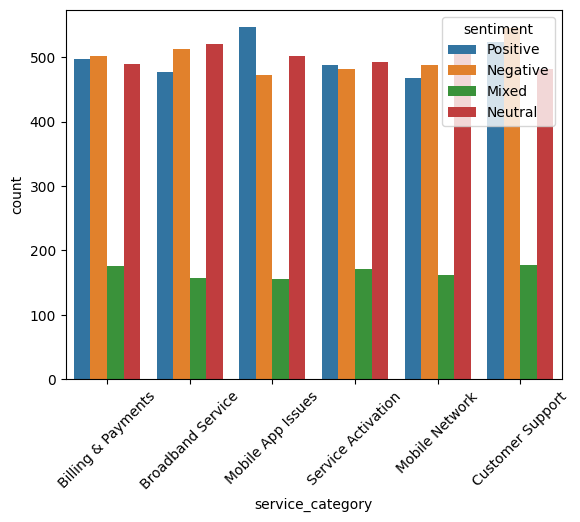

In [8]:
import seaborn as sns

sns.countplot(data=df, x='service_category', hue='sentiment')
plt.xticks(rotation=45)
plt.show()

### Message Length Analysis

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(10, 6))

# Plot with a specific palette
# 'viridis', 'magma', or 'Set2' are great options
ax = sns.boxplot(data=df, x='sentiment', y='length', palette='Set2', hue='sentiment', legend=False)

# Add titles and labels
plt.title('Analysis of Message Length by Sentiment', fontsize=16, pad=20)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Message Length (Characters/Words)', fontsize=12)

# Optional: Remove the top and right spines for a "cleaner" look
sns.despine()

plt.show()

ValueError: Could not interpret value `length` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

Mixed Sentiment stands out: Messages categorized as "Mixed" are significantly longer than the others. The entire "box" for Mixed sentiment sits higher than the medians of the other three categories. This suggests that users expressing complex or conflicting emotions tend to use more words to explain themselves.

Consistency across Positive, Negative, and Neutral: These three categories share a very similar range. Their "boxes" (representing the middle 50% of the data) mostly overlap between a length of 39 and 46.

Negative messages are more "compact": The box for Negative sentiment is slightly smaller and has a higher median than Positive or Neutral. This indicates that negative feedback in your dataset is consistently mid-length, whereas Positive and Neutral messages have more variation.

## 3.SENTIMENT ANALYSIS

### Approach 1: Using Transformers

# DistilBERT

In [ ]:
pip install transformers datasets accelerate scikit-learn

In [3]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

classifier("Internet speed is very slow")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'NEGATIVE', 'score': 0.9996585845947266}]

In [4]:
import pandas as pd

df = pd.read_csv("telecom_feedback_dataset.csv")
df.head()

,feedback,sentiment,service_category
0,Billing & Payments has improved a lot recently,Positive,Billing & Payments
1,Facing constant issues with Broadband Service,Negative,Broadband Service
2,Mobile App Issues works well sometimes but fai...,Mixed,Mobile App Issues
3,Great experience using Mobile App Issues,Positive,Mobile App Issues
4,Broadband Service has improved a lot recently,Positive,Broadband Service


In [5]:
label_map = {
    0: "Positive",
    1: "Negative",
    2: "Neutral",
    3: "Mixed"
}
df["label"] = df["sentiment"].map(label_map)
df.head()

,feedback,sentiment,service_category,label
0,Billing & Payments has improved a lot recently,Positive,Billing & Payments,NaN
1,Facing constant issues with Broadband Service,Negative,Broadband Service,NaN
2,Mobile App Issues works well sometimes but fai...,Mixed,Mobile App Issues,NaN
3,Great experience using Mobile App Issues,Positive,Mobile App Issues,NaN
4,Broadband Service has improved a lot recently,Positive,Broadband Service,NaN


In [6]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["feedback"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42
)

In [7]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

In [15]:
import torch

class TelecomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        
        # FIX: ensure label is integer (not float, not list)
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        
        return item

    def __len__(self):
        return len(self.labels)

In [16]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
pip install transformers[torch]

In [25]:
pip install 'accelerate>=1.1.0

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

In [ ]:
from transformers import Trainer, TrainingArguments

# IMPORTANT: force correct problem type
model.config.problem_type = "single_label_classification"
model.config.num_labels = 4

# make sure labels are integers (VERY IMPORTANT)
def fix_labels(example):
    example["labels"] = int(example["labels"])
    return example

train_dataset = train_dataset.map(fix_labels)
val_dataset = val_dataset.map(fix_labels)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",   # fixed typo (was eval_strategy)
    save_strategy="epoch",
    logging_steps=50,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

In [ ]:
trainer.evaluate()

# Calculate Accuracy

In [ ]:
predictions = trainer.predict(val_dataset)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

pred_labels = np.argmax(predictions.predictions, axis=1)

accuracy = accuracy_score(val_labels, pred_labels)
print("Accuracy:", accuracy)

print(classification_report(val_labels, pred_labels))

In [ ]:
model.save_pretrained("/content/telecom_sentiment_model")
tokenizer.save_pretrained("/content/telecom_sentiment_model")

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="/content/telecom_sentiment_model",
    tokenizer="/content/telecom_sentiment_model"
)

print(classifier("Internet speed is slow but customer support is good"))

In [ ]:
def predict(text):
    result = classifier(text)[0]
    label_id = int(result["label"].replace("LABEL_", ""))
    return label_map[label_id], result["score"]

print(predict("The technician arrived right on time and fixed the router in 5 minutes, stellar service!"))